# 01 - Exploratory Data Analysis & Seasonal Risk Profiling

**Research Question 3:** How has Vancouver's wildfire smoke season changed from 2015 to 2025 — are smoke events becoming more frequent, longer, or more intense?

This notebook explores the merged dataset and characterizes Vancouver's smoke exposure over the past decade.

**Sections:**
1. Data Loading & Overview
2. PM2.5 Distribution & Summary Statistics
3. Time Series of Daily PM2.5
4. Seasonal Patterns (Monthly Averages)
5. Smoke Event Analysis (PM2.5 > 25 µg/m³)
6. Year-over-Year Smoke Season Comparison
7. Fire Activity Trends
8. Weather–PM2.5 Relationships
9. Correlation Heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Smoke event threshold (BC AQHI moderate risk)
SMOKE_THRESHOLD = 25  # ug/m3 daily mean PM2.5

# Paths
DATA_DIR = Path("..") / "data" / "processed"
DATASET_PATH = DATA_DIR / "merged" / "dataset.csv"

## 1. Data Loading & Overview

In [2]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
df.head()

Dataset shape: (3654, 90)
Date range: 2015-01-01 to 2025-01-01

Column types:
float64           79
int64             10
datetime64[ns]     1
Name: count, dtype: int64


,date,pm25,pm25_median,pm25_max,pm25_min,pm25_std,n_readings,n_stations,fire_count_close,fire_frp_sum_close,...,fire_frp_mean_total_lag1,fire_frp_mean_total_lag2,fire_frp_mean_total_lag3,fire_mean_distance_km_lag1,fire_mean_distance_km_lag2,fire_mean_distance_km_lag3,month,day_of_year,is_fire_season,year
0,2015-01-01,13.573184,11.75,43.6,1.5,8.038201,358,16,1.0,0.72,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,2015
1,2015-01-02,11.144304,10.40,28.6,2.7,4.376180,395,17,0.0,0.00,...,1.460,NaN,NaN,188.993921,NaN,NaN,1,2,0,2015
2,2015-01-03,8.972549,7.90,27.1,1.1,4.794267,408,17,0.0,0.00,...,18.645,1.460,NaN,344.054628,188.993921,NaN,1,3,0,2015
3,2015-01-04,2.898039,2.80,10.8,0.4,1.478543,408,17,0.0,0.00,...,2.850,18.645,1.460,755.843253,344.054628,188.993921,1,4,0,2015
4,2015-01-05,3.692147,3.30,18.0,0.2,2.499594,382,17,0.0,0.00,...,5.530,2.850,18.645,470.088121,755.843253,344.054628,1,5,0,2015


In [3]:
# Missing values summary (only columns with missing data)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Columns with missing values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")
else:
    print("No missing values.")

Columns with missing values:
  pm25_lag7: 7 (0.2%)
  fire_frp_mean_medium_lag3: 3 (0.1%)
  fire_frp_mean_close_lag3: 3 (0.1%)
  fire_frp_mean_total_lag3: 3 (0.1%)
  fire_frp_sum_total_lag3: 3 (0.1%)
  fire_count_total_lag3: 3 (0.1%)
  fire_frp_mean_far_lag3: 3 (0.1%)
  fire_frp_sum_far_lag3: 3 (0.1%)
  fire_count_far_lag3: 3 (0.1%)
  fire_frp_sum_medium_lag3: 3 (0.1%)
  fire_count_medium_lag3: 3 (0.1%)
  fire_mean_distance_km_lag3: 3 (0.1%)
  fire_count_close_lag3: 3 (0.1%)
  fire_frp_sum_close_lag3: 3 (0.1%)
  pm25_lag3: 3 (0.1%)
  fire_frp_mean_close_lag2: 2 (0.1%)
  fire_count_close_lag2: 2 (0.1%)
  fire_frp_mean_far_lag2: 2 (0.1%)
  fire_frp_sum_total_lag2: 2 (0.1%)
  fire_frp_sum_far_lag2: 2 (0.1%)
  fire_frp_sum_close_lag2: 2 (0.1%)
  fire_count_far_lag2: 2 (0.1%)
  fire_frp_mean_total_lag2: 2 (0.1%)
  pm25_lag2: 2 (0.1%)
  fire_frp_mean_medium_lag2: 2 (0.1%)
  fire_frp_sum_medium_lag2: 2 (0.1%)
  fire_mean_distance_km_lag2: 2 (0.1%)
  fire_count_medium_lag2: 2 (0.1%)
  fire_coun

In [4]:
# Key variable statistics
key_cols = ["pm25", "pm25_max", "fire_count_total", "fire_frp_sum_total",
            "temperature_2m_mean", "relative_humidity_2m_mean",
            "wind_speed_10m_mean", "precipitation_sum"]
df[key_cols].describe().round(2)

,pm25,pm25_max,fire_count_total,fire_frp_sum_total,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_mean,precipitation_sum
count,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00
mean,5.73,28.02,289.02,4514.90,10.48,80.46,9.59,5.11
std,7.02,29.12,1068.17,20387.79,6.20,10.17,4.14,9.28
min,1.03,4.60,0.00,0.00,-11.62,26.29,1.66,0.00
25%,3.33,14.62,8.00,22.88,5.63,74.25,6.50,0.00
50%,4.48,20.30,25.00,164.02,9.83,81.62,8.58,0.40
75%,6.22,30.08,111.00,1289.77,15.59,88.36,11.91,6.57
max,163.52,420.70,14341.00,401855.29,30.98,99.04,30.50,78.60


## 2. PM2.5 Distribution

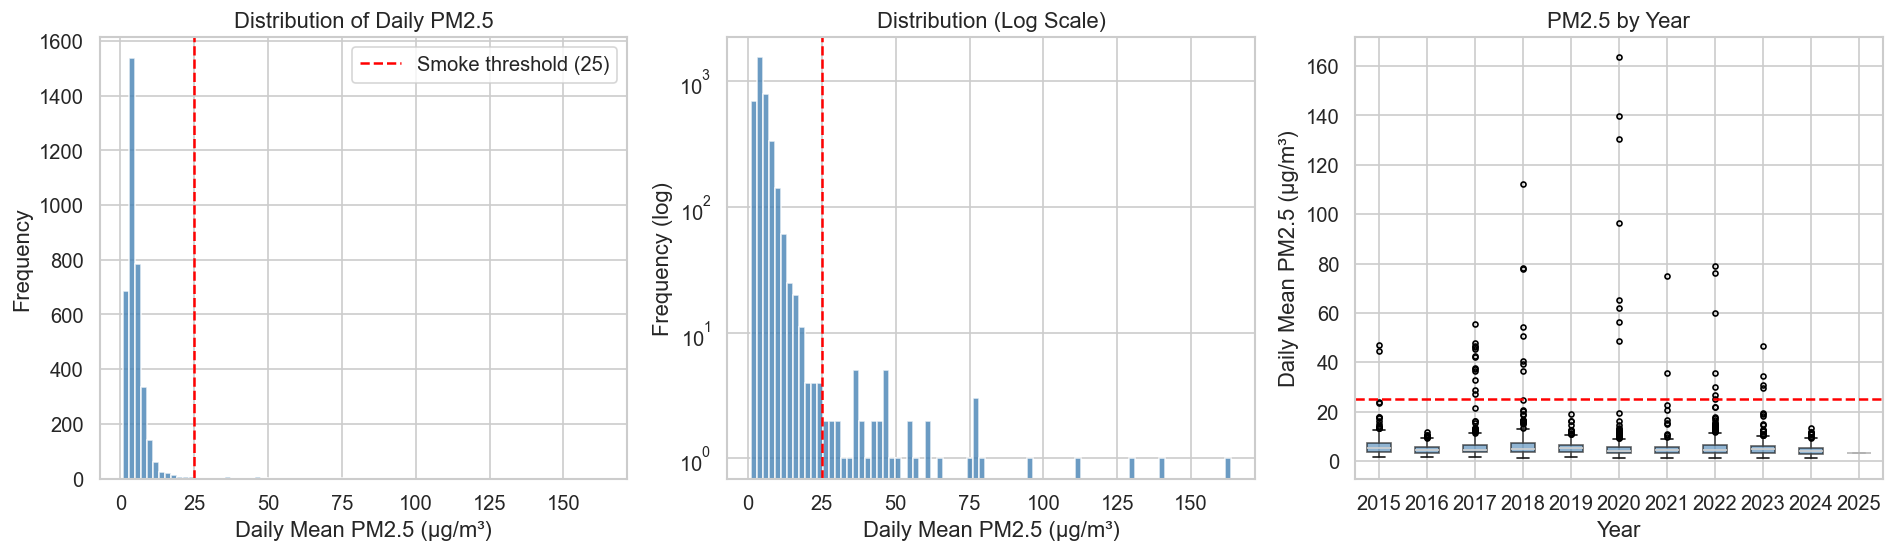


PM2.5 percentiles:
  50th percentile: 4.48 µg/m³
  75th percentile: 6.22 µg/m³
  90th percentile: 8.65 µg/m³
  95th percentile: 11.03 µg/m³
  99th percentile: 31.91 µg/m³


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram of daily mean PM2.5
axes[0].hist(df["pm25"], bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Smoke threshold ({SMOKE_THRESHOLD})")
axes[0].set_xlabel("Daily Mean PM2.5 (µg/m³)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Daily PM2.5")
axes[0].legend()

# Log-scale histogram to see tail
axes[1].hist(df["pm25"], bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Daily Mean PM2.5 (µg/m³)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_yscale("log")
axes[1].set_title("Distribution (Log Scale)")

# Box plot by year
df.boxplot(column="pm25", by="year", ax=axes[2], sym=".", patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[2].axhline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Daily Mean PM2.5 (µg/m³)")
axes[2].set_title("PM2.5 by Year")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../figures/pm25_distribution.png", bbox_inches="tight")
plt.show()

# Print percentiles
print("\nPM2.5 percentiles:")
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df["pm25"], p)
    print(f"  {p}th percentile: {val:.2f} µg/m³")

## 3. Time Series of Daily PM2.5

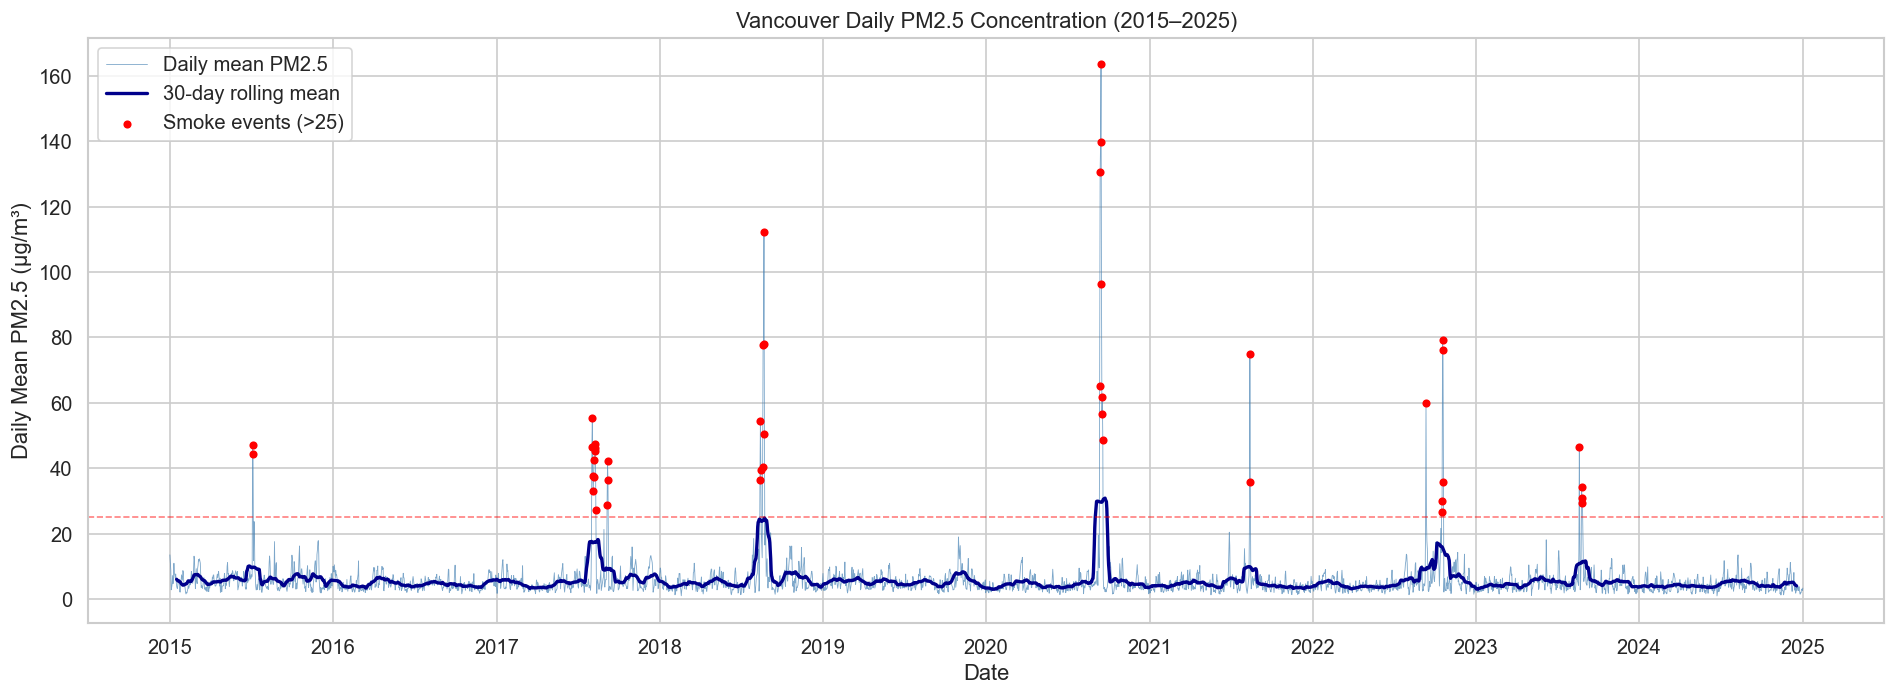

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df["date"], df["pm25"], linewidth=0.5, color="steelblue", alpha=0.7, label="Daily mean PM2.5")

# 30-day rolling average
rolling = df["pm25"].rolling(30, center=True).mean()
ax.plot(df["date"], rolling, linewidth=2, color="darkblue", label="30-day rolling mean")

# Highlight smoke events
smoke_mask = df["pm25"] > SMOKE_THRESHOLD
ax.scatter(df.loc[smoke_mask, "date"], df.loc[smoke_mask, "pm25"],
           color="red", s=15, zorder=5, label=f"Smoke events (>{SMOKE_THRESHOLD})")

ax.axhline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Mean PM2.5 (µg/m³)")
ax.set_title("Vancouver Daily PM2.5 Concentration (2015–2025)")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../figures/pm25_timeseries.png", bbox_inches="tight")
plt.show()

## 4. Seasonal Patterns (Monthly Averages)

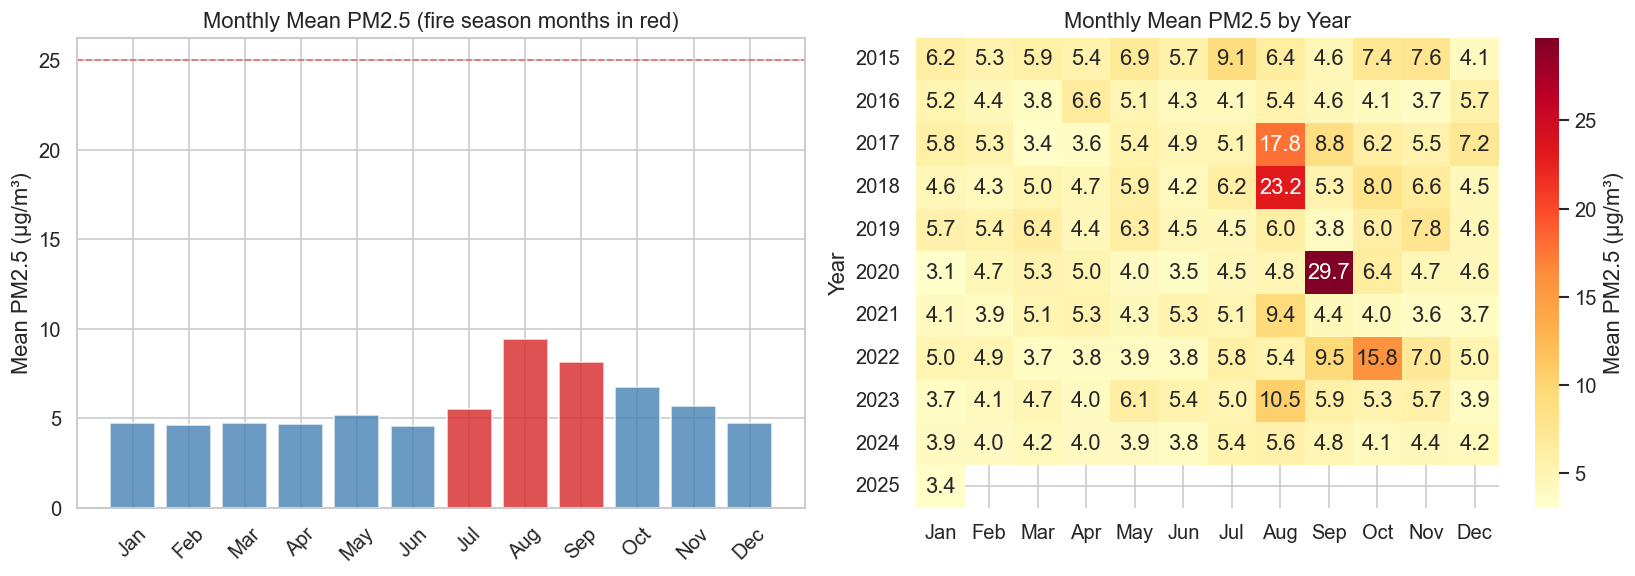

,mean,median,max,std
Jan,4.72,3.95,13.57,2.27
Feb,4.62,4.34,13.17,1.94
Mar,4.75,4.13,12.83,2.27
Apr,4.67,4.21,10.49,1.92
May,5.18,4.95,11.21,2.03
Jun,4.54,4.20,20.49,2.28
Jul,5.50,4.59,47.08,4.32
Aug,9.45,5.47,112.09,12.97
Sep,8.14,4.60,163.52,16.85
Oct,6.72,4.92,79.19,7.16


In [7]:
monthly = df.groupby("month")["pm25"].agg(["mean", "median", "max", "std"]).round(2)
monthly.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly mean PM2.5
colors = ["#d62728" if m in ["Jul", "Aug", "Sep"] else "steelblue" for m in monthly.index]
axes[0].bar(monthly.index, monthly["mean"], color=colors, edgecolor="white", alpha=0.8)
axes[0].axhline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1, alpha=0.5)
axes[0].set_ylabel("Mean PM2.5 (µg/m³)")
axes[0].set_title("Monthly Mean PM2.5 (fire season months in red)")
axes[0].tick_params(axis="x", rotation=45)

# Monthly PM2.5 heatmap by year
pivot = df.groupby(["year", "month"])["pm25"].mean().unstack()
pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "Mean PM2.5 (µg/m³)"})
axes[1].set_title("Monthly Mean PM2.5 by Year")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.savefig("../figures/pm25_seasonal_patterns.png", bbox_inches="tight")
plt.show()

monthly

## 5. Smoke Event Analysis (PM2.5 > 25 µg/m³)

A **smoke event** is defined as any day where the daily mean PM2.5 exceeds 25 µg/m³ (BC AQHI moderate risk level).

In [8]:
df["is_smoke_event"] = (df["pm25"] > SMOKE_THRESHOLD).astype(int)

# Identify contiguous smoke episodes
# An episode is a consecutive run of smoke event days
df["smoke_episode_id"] = (df["is_smoke_event"].diff() != 0).cumsum()
df["smoke_episode_id"] = df["smoke_episode_id"].where(df["is_smoke_event"] == 1)

smoke_episodes = (
    df[df["is_smoke_event"] == 1]
    .groupby("smoke_episode_id")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        duration_days=("date", "count"),
        mean_pm25=("pm25", "mean"),
        max_pm25=("pm25", "max"),
        peak_pm25_max=("pm25_max", "max"),
        year=("year", "first")
    )
    .reset_index(drop=True)
)

print(f"Total smoke event days: {df['is_smoke_event'].sum()}")
print(f"Total smoke episodes (contiguous): {len(smoke_episodes)}")
print(f"\nLongest episode: {smoke_episodes['duration_days'].max()} days")
print(f"Mean episode duration: {smoke_episodes['duration_days'].mean():.1f} days")
print(f"Max daily mean PM2.5 during smoke events: {smoke_episodes['max_pm25'].max():.1f} µg/m³")
print()
smoke_episodes.sort_values("max_pm25", ascending=False).head(10)

Total smoke event days: 43
Total smoke episodes (contiguous): 11

Longest episode: 10 days
Mean episode duration: 3.9 days
Max daily mean PM2.5 during smoke events: 163.5 µg/m³



,start_date,end_date,duration_days,mean_pm25,max_pm25,peak_pm25_max,year
5,2020-09-11,2020-09-18,8,95.281852,163.516986,243.1,2020
4,2018-08-19,2018-08-23,5,71.798428,112.089755,380.0,2018
8,2022-10-16,2022-10-20,5,49.547339,79.186652,345.8,2022
6,2021-08-13,2021-08-14,2,55.303426,74.824835,201.7,2021
7,2022-09-11,2022-09-11,1,59.978070,59.978070,355.6,2022
1,2017-08-02,2017-08-11,10,41.927553,55.482558,159.8,2017
3,2018-08-13,2018-08-15,3,43.435155,54.475658,165.5,2018
0,2015-07-05,2015-07-06,2,45.729595,47.076852,295.3,2015
9,2023-08-20,2023-08-20,1,46.625330,46.625330,420.7,2023
2,2017-09-05,2017-09-07,3,35.833046,42.275114,124.8,2017


## 6. Year-over-Year Smoke Season Comparison

This directly addresses **RQ3**: Are smoke events becoming more frequent, longer, or more intense?

In [9]:
# Annual smoke metrics
annual_smoke = (
    df.groupby("year")
    .agg(
        smoke_days=("is_smoke_event", "sum"),
        annual_mean_pm25=("pm25", "mean"),
        annual_max_pm25=("pm25", "max"),
        fire_season_mean_pm25=("pm25", lambda x: x.iloc[0]),  # placeholder, compute below
    )
    .reset_index()
)

# Compute fire season (Jun-Sep) mean PM2.5 properly
fire_season = df[df["is_fire_season"] == 1].groupby("year")["pm25"].mean()
annual_smoke["fire_season_mean_pm25"] = annual_smoke["year"].map(fire_season)

# Episode stats per year
ep_annual = smoke_episodes.groupby("year").agg(
    n_episodes=("duration_days", "count"),
    longest_episode=("duration_days", "max"),
    mean_episode_duration=("duration_days", "mean"),
    worst_episode_pm25=("max_pm25", "max")
).reset_index()

annual_smoke = annual_smoke.merge(ep_annual, on="year", how="left").fillna(0)
annual_smoke[["n_episodes", "longest_episode"]] = annual_smoke[["n_episodes", "longest_episode"]].astype(int)

print("Annual Smoke Season Summary:")
annual_smoke

Annual Smoke Season Summary:


,year,smoke_days,annual_mean_pm25,annual_max_pm25,fire_season_mean_pm25,n_episodes,longest_episode,mean_episode_duration,worst_episode_pm25
0,2015,2,6.228384,47.076852,6.492628,1,2,2.0,47.076852
1,2016,0,4.743090,11.726316,4.591784,0,0,0.0,0.000000
2,2017,13,6.612176,55.482558,9.190129,2,10,6.5,55.482558
3,2018,8,6.898652,112.089755,9.791111,2,5,4.0,112.089755
4,2019,0,5.441838,19.045154,4.704245,0,0,0.0,0.000000
5,2020,8,6.657391,163.516986,10.548865,1,8,8.0,163.516986
6,2021,2,4.863398,74.824835,6.084001,1,2,2.0,74.824835
7,2022,6,6.156442,79.186652,6.141023,2,5,3.0,79.186652
8,2023,4,5.368744,46.625330,6.718337,2,3,2.0,46.625330
9,2024,0,4.364772,13.561734,4.911334,0,0,0.0,0.000000


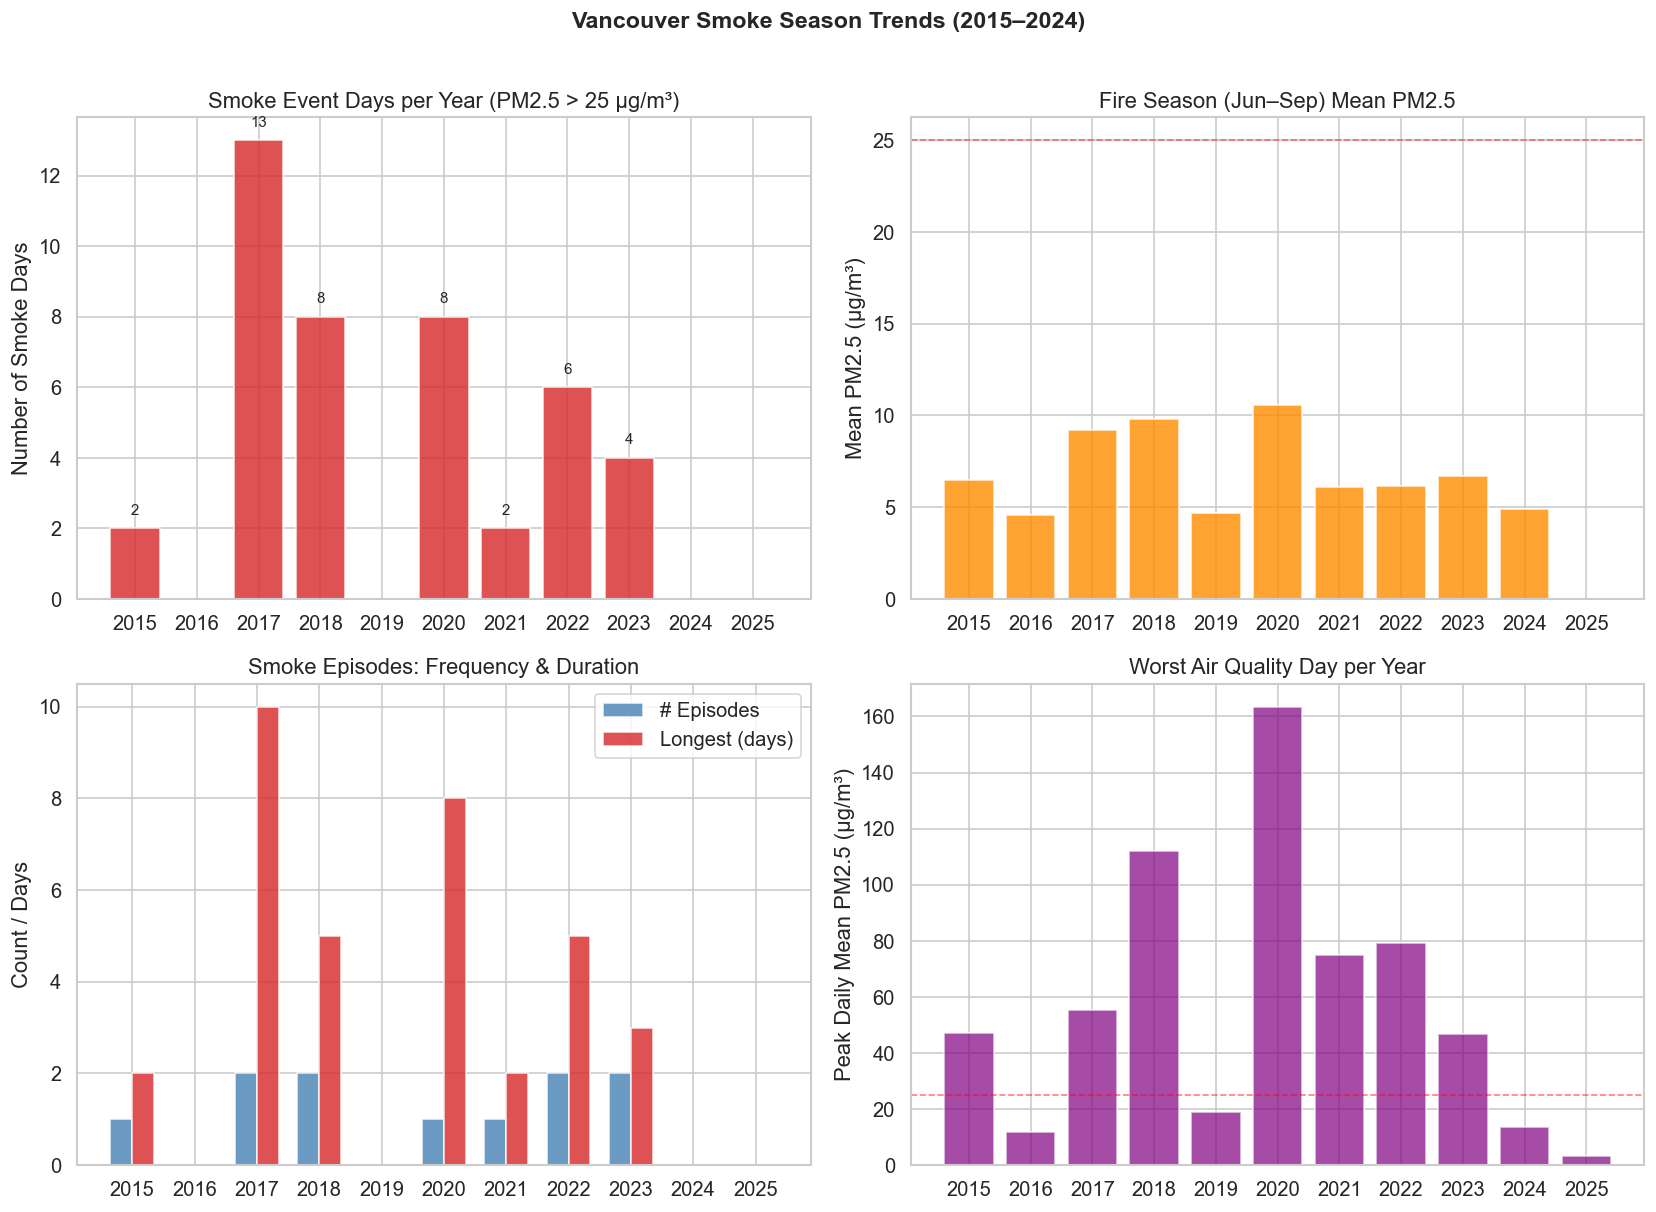

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

years = annual_smoke["year"]

# Smoke days per year
bars = axes[0, 0].bar(years, annual_smoke["smoke_days"], color="#d62728", edgecolor="white", alpha=0.8)
axes[0, 0].set_ylabel("Number of Smoke Days")
axes[0, 0].set_title("Smoke Event Days per Year (PM2.5 > 25 µg/m³)")
axes[0, 0].set_xticks(years)
for bar, val in zip(bars, annual_smoke["smoke_days"]):
    if val > 0:
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        str(int(val)), ha="center", va="bottom", fontsize=9)

# Fire season mean PM2.5
axes[0, 1].bar(years, annual_smoke["fire_season_mean_pm25"], color="darkorange", edgecolor="white", alpha=0.8)
axes[0, 1].axhline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1, alpha=0.5)
axes[0, 1].set_ylabel("Mean PM2.5 (µg/m³)")
axes[0, 1].set_title("Fire Season (Jun–Sep) Mean PM2.5")
axes[0, 1].set_xticks(years)

# Number of episodes and longest duration
ax2 = axes[1, 0]
bar_width = 0.35
x = np.arange(len(years))
ax2.bar(x - bar_width/2, annual_smoke["n_episodes"], bar_width,
        label="# Episodes", color="steelblue", edgecolor="white", alpha=0.8)
ax2.bar(x + bar_width/2, annual_smoke["longest_episode"], bar_width,
        label="Longest (days)", color="#d62728", edgecolor="white", alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_ylabel("Count / Days")
ax2.set_title("Smoke Episodes: Frequency & Duration")
ax2.legend()

# Peak PM2.5 per year
axes[1, 1].bar(years, annual_smoke["annual_max_pm25"], color="purple", edgecolor="white", alpha=0.7)
axes[1, 1].axhline(SMOKE_THRESHOLD, color="red", linestyle="--", linewidth=1, alpha=0.5)
axes[1, 1].set_ylabel("Peak Daily Mean PM2.5 (µg/m³)")
axes[1, 1].set_title("Worst Air Quality Day per Year")
axes[1, 1].set_xticks(years)

plt.suptitle("Vancouver Smoke Season Trends (2015–2024)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/smoke_season_trends.png", bbox_inches="tight")
plt.show()

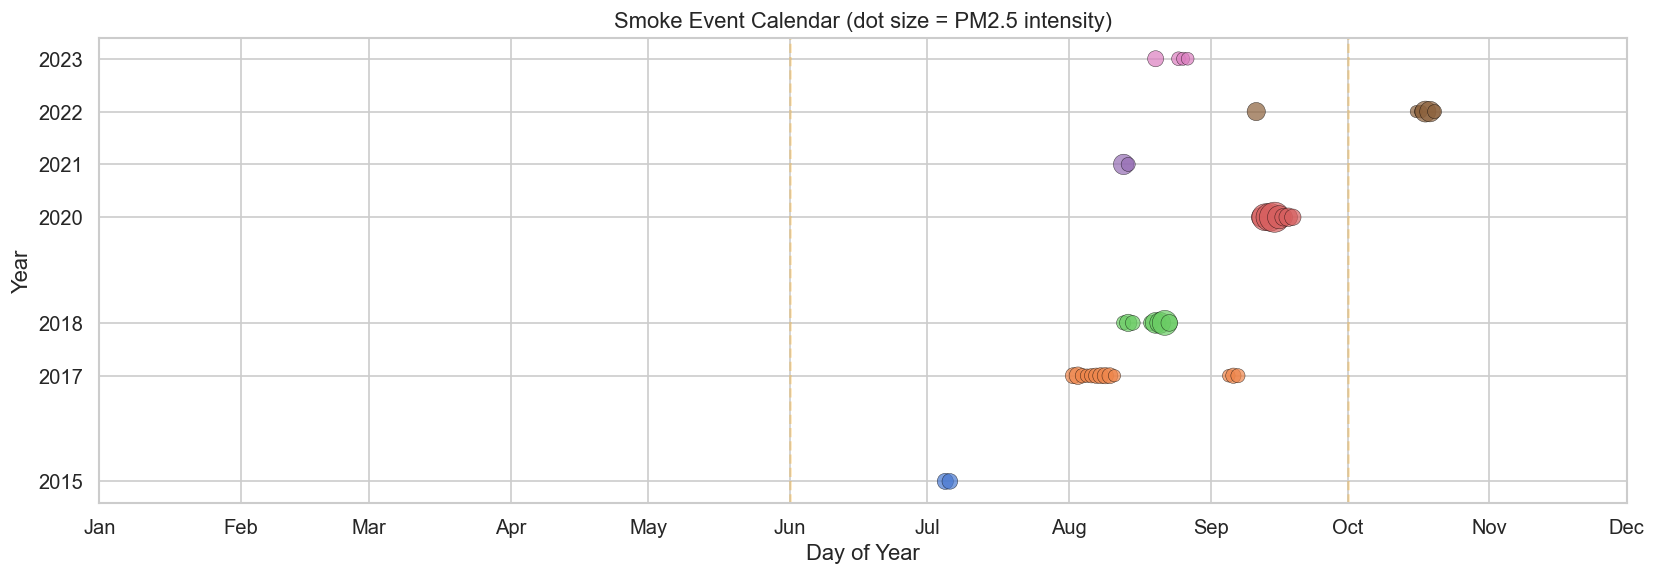

In [11]:
# Smoke season calendar view -- which dates saw smoke events each year?
smoke_days_detail = df[df["is_smoke_event"] == 1][["date", "year", "month", "day_of_year", "pm25"]].copy()

fig, ax = plt.subplots(figsize=(14, 5))
for yr in sorted(smoke_days_detail["year"].unique()):
    subset = smoke_days_detail[smoke_days_detail["year"] == yr]
    ax.scatter(subset["day_of_year"], [yr] * len(subset), s=subset["pm25"] * 2,
              alpha=0.7, edgecolors="black", linewidth=0.3)

ax.set_xlabel("Day of Year")
ax.set_ylabel("Year")
ax.set_title("Smoke Event Calendar (dot size = PM2.5 intensity)")
ax.set_yticks(sorted(smoke_days_detail["year"].unique()))

# Add month labels
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.axvline(152, color="orange", linestyle="--", alpha=0.3, label="Jun 1")
ax.axvline(274, color="orange", linestyle="--", alpha=0.3, label="Oct 1")

plt.tight_layout()
plt.savefig("../figures/smoke_event_calendar.png", bbox_inches="tight")
plt.show()

## 7. Fire Activity Trends

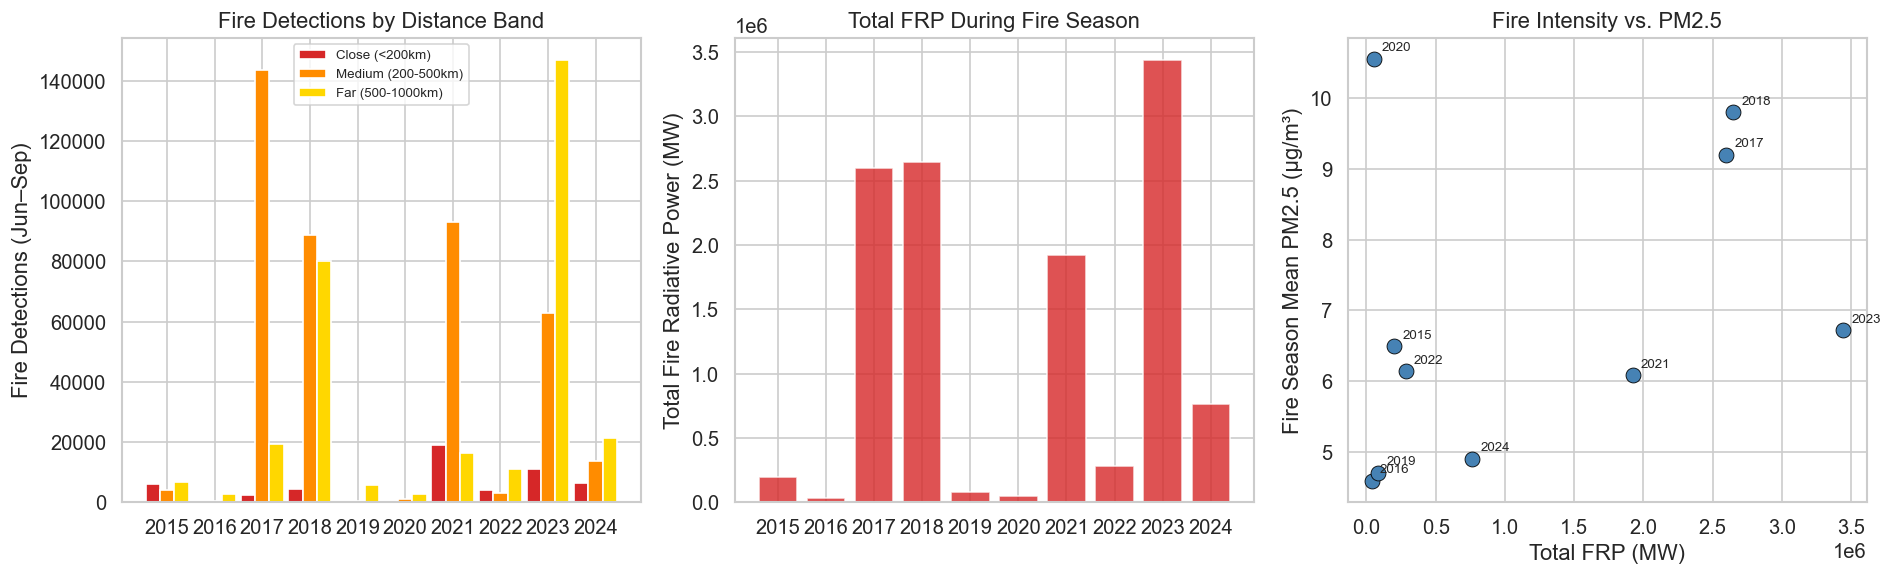

In [12]:
# Annual fire stats
fire_season_df = df[df["is_fire_season"] == 1]

annual_fires = fire_season_df.groupby("year").agg(
    total_detections=("fire_count_total", "sum"),
    close_detections=("fire_count_close", "sum"),
    medium_detections=("fire_count_medium", "sum"),
    total_frp=("fire_frp_sum_total", "sum"),
    active_fire_days=("fire_count_total", lambda x: (x > 0).sum())
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fire detections by distance band
x = np.arange(len(annual_fires))
w = 0.3
axes[0].bar(x - w, annual_fires["close_detections"], w, label="Close (<200km)", color="#d62728")
axes[0].bar(x, annual_fires["medium_detections"], w, label="Medium (200-500km)", color="darkorange")
far = fire_season_df.groupby("year")["fire_count_far"].sum().values
axes[0].bar(x + w, far, w, label="Far (500-1000km)", color="gold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(annual_fires["year"])
axes[0].set_ylabel("Fire Detections (Jun–Sep)")
axes[0].set_title("Fire Detections by Distance Band")
axes[0].legend(fontsize=8)

# Total FRP
axes[1].bar(annual_fires["year"], annual_fires["total_frp"], color="#d62728", edgecolor="white", alpha=0.8)
axes[1].set_ylabel("Total Fire Radiative Power (MW)")
axes[1].set_title("Total FRP During Fire Season")
axes[1].set_xticks(annual_fires["year"])

# Fire activity vs PM2.5 scatter
merged = annual_fires.merge(annual_smoke[["year", "fire_season_mean_pm25"]], on="year")
axes[2].scatter(merged["total_frp"], merged["fire_season_mean_pm25"],
               s=80, color="steelblue", edgecolors="black", linewidth=0.5)
for _, row in merged.iterrows():
    axes[2].annotate(str(int(row["year"])),
                    (row["total_frp"], row["fire_season_mean_pm25"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[2].set_xlabel("Total FRP (MW)")
axes[2].set_ylabel("Fire Season Mean PM2.5 (µg/m³)")
axes[2].set_title("Fire Intensity vs. PM2.5")

plt.tight_layout()
plt.savefig("../figures/fire_activity_trends.png", bbox_inches="tight")
plt.show()

## 8. Weather–PM2.5 Relationships

/var/folders/59/wlsynccn3t1dxv7388zs9g_80000gn/T/ipykernel_25864/1597774238.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_vals, smoke_vals], labels=["Normal", "Smoke"],
/var/folders/59/wlsynccn3t1dxv7388zs9g_80000gn/T/ipykernel_25864/1597774238.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_vals, smoke_vals], labels=["Normal", "Smoke"],
/var/folders/59/wlsynccn3t1dxv7388zs9g_80000gn/T/ipykernel_25864/1597774238.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_vals, smoke_vals], labels=["Normal", "Smoke"],
/var/folders/59/wlsynccn3t1dxv7388zs9g_8

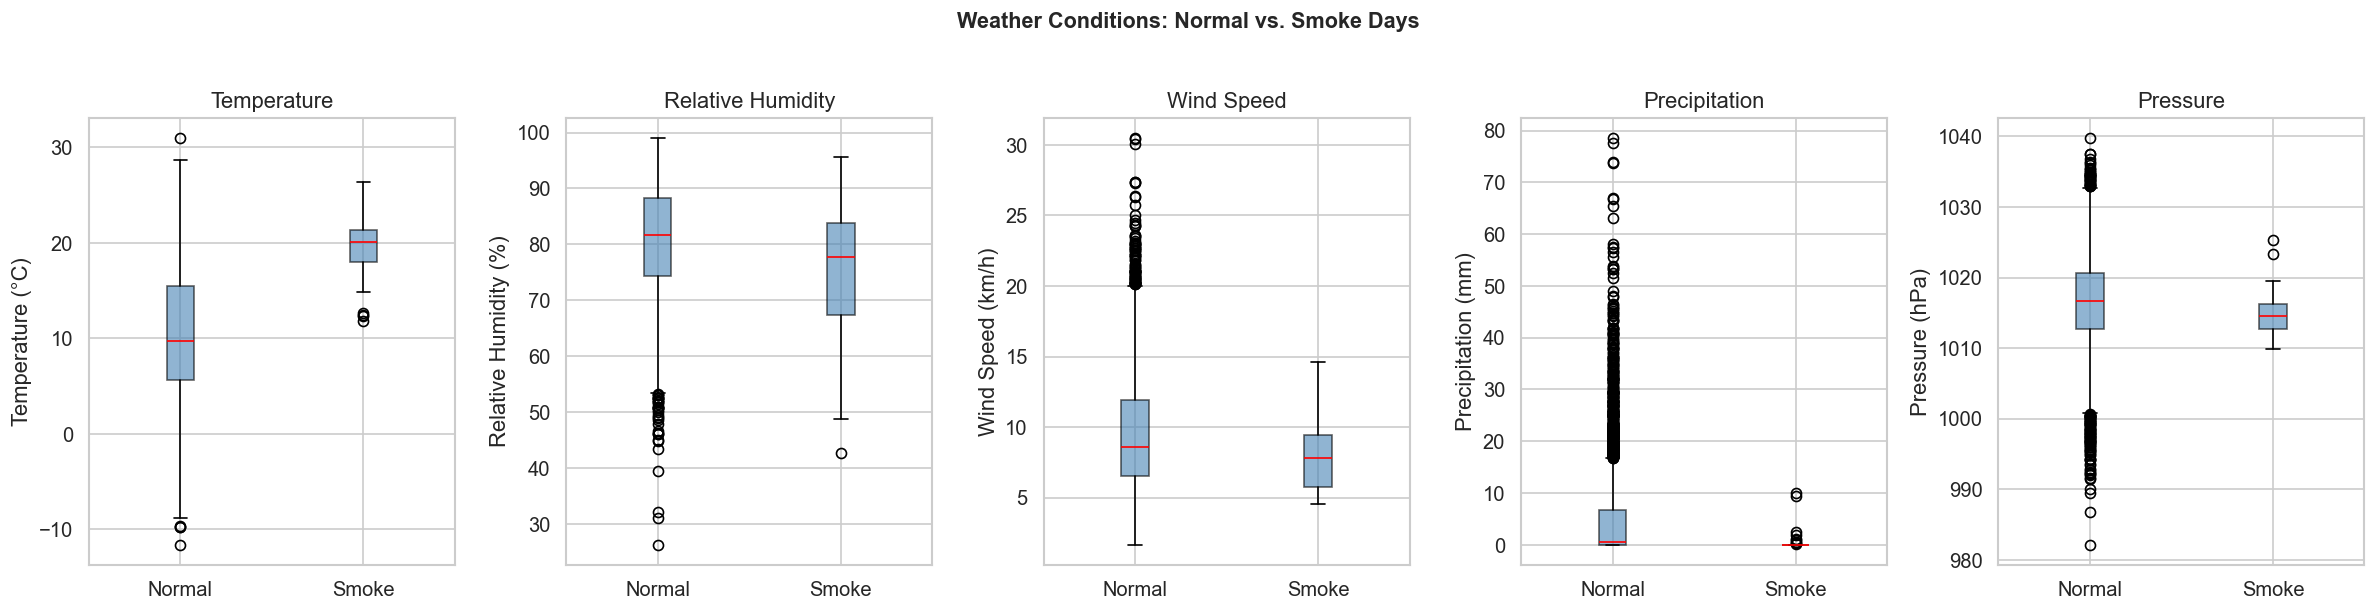


Mean values comparison:
  Temperature (°C)                Normal:    10.37  Smoke:    19.53  Diff: +9.16
  Relative Humidity (%)           Normal:    80.52  Smoke:    75.67  Diff: -4.85
  Wind Speed (km/h)               Normal:     9.61  Smoke:     8.15  Diff: -1.46
  Precipitation (mm)              Normal:     5.16  Smoke:     0.62  Diff: -4.54
  Pressure (hPa)                  Normal:  1016.57  Smoke:  1014.88  Diff: -1.69


In [13]:
# Weather conditions during smoke vs. non-smoke days
weather_vars = ["temperature_2m_mean", "relative_humidity_2m_mean",
                "wind_speed_10m_mean", "precipitation_sum", "pressure_msl_mean"]
labels = ["Temperature (°C)", "Relative Humidity (%)",
          "Wind Speed (km/h)", "Precipitation (mm)", "Pressure (hPa)"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, var, label in zip(axes, weather_vars, labels):
    smoke_vals = df.loc[df["is_smoke_event"] == 1, var].dropna()
    normal_vals = df.loc[df["is_smoke_event"] == 0, var].dropna()

    ax.boxplot([normal_vals, smoke_vals], labels=["Normal", "Smoke"],
              patch_artist=True,
              boxprops=dict(facecolor="steelblue", alpha=0.6),
              medianprops=dict(color="red"))
    ax.set_ylabel(label)
    ax.set_title(label.split("(")[0].strip())

plt.suptitle("Weather Conditions: Normal vs. Smoke Days", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/weather_smoke_comparison.png", bbox_inches="tight")
plt.show()

# Print summary table
print("\nMean values comparison:")
for var, label in zip(weather_vars, labels):
    normal = df.loc[df["is_smoke_event"] == 0, var].mean()
    smoke = df.loc[df["is_smoke_event"] == 1, var].mean()
    print(f"  {label:30s}  Normal: {normal:8.2f}  Smoke: {smoke:8.2f}  Diff: {smoke - normal:+.2f}")

## 9. Correlation Heatmap

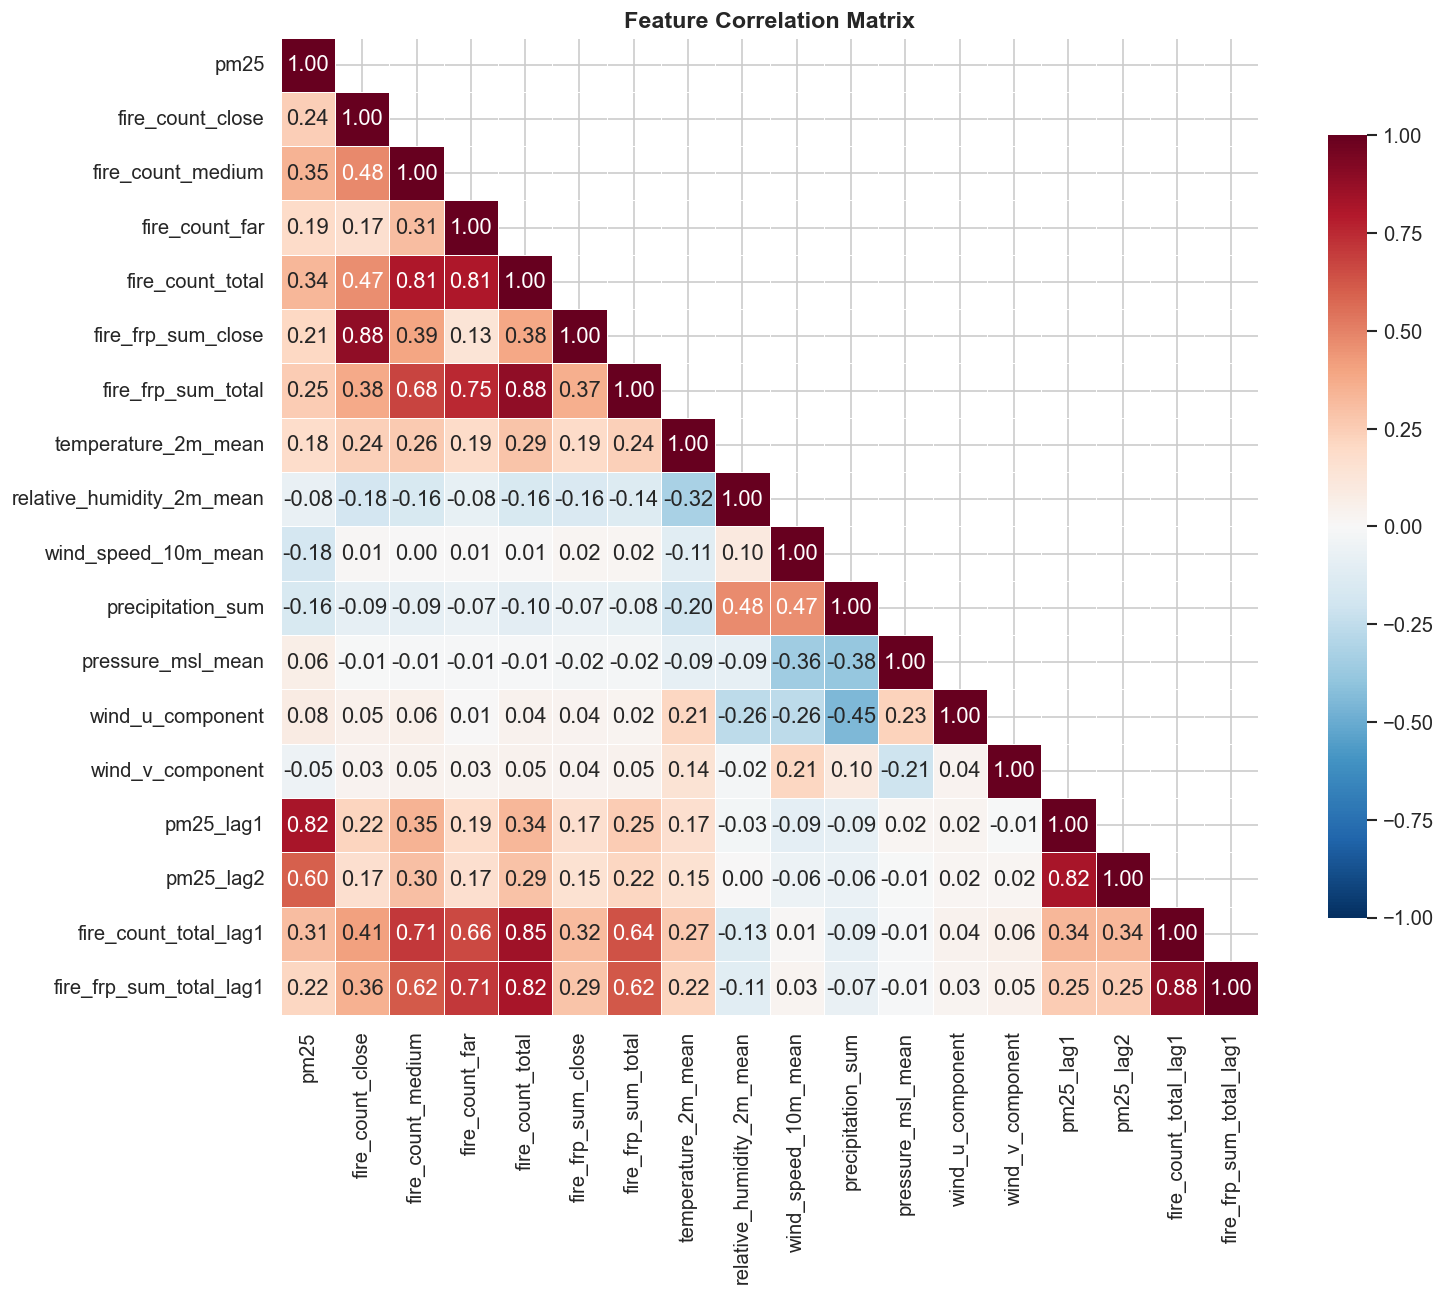


Top correlations with PM2.5:
  pm25_lag1                           +0.822
  pm25_lag2                           +0.597
  fire_count_medium                   +0.345
  fire_count_total                    +0.336
  fire_count_total_lag1               +0.307
  fire_frp_sum_total                  +0.255
  fire_count_close                    +0.243
  fire_frp_sum_total_lag1             +0.217
  fire_frp_sum_close                  +0.206
  fire_count_far                      +0.189


In [14]:
# Select most relevant features for correlation analysis
corr_cols = [
    "pm25",
    "fire_count_close", "fire_count_medium", "fire_count_far", "fire_count_total",
    "fire_frp_sum_close", "fire_frp_sum_total",
    "temperature_2m_mean", "relative_humidity_2m_mean",
    "wind_speed_10m_mean", "precipitation_sum", "pressure_msl_mean",
    "wind_u_component", "wind_v_component",
    "pm25_lag1", "pm25_lag2",
    "fire_count_total_lag1", "fire_frp_sum_total_lag1",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Top correlations with PM2.5
pm25_corr = corr_matrix["pm25"].drop("pm25").abs().sort_values(ascending=False)
print("\nTop correlations with PM2.5:")
for feat, val in pm25_corr.head(10).items():
    sign = "+" if corr_matrix.loc["pm25", feat] > 0 else "-"
    print(f"  {feat:35s} {sign}{val:.3f}")

## Key Findings

Summarize the key findings from this EDA below after running all cells:

1. **PM2.5 Distribution:** ...
2. **Seasonal Pattern:** ...
3. **Smoke Season Trends (RQ3):** ...
4. **Weather Associations:** ...
5. **Strongest Predictors:** ...